<a href="https://colab.research.google.com/github/adoraonubogu-png/Adora_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

df = pd.read_csv('car_purchase_data.csv')

df.head()

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Step 2: Split features and target

In [3]:
# independent variables (Age and Salary) and dependent variable (Purchased)
X = df[['Age', 'Salary']].values
y = df['Purchased'].values

### Step 3: Train/Test Split

In [4]:
# Split into Training set (80%) and Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 4: Feature Scaling

In [5]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Step 5: Train Logistic Regression Model

In [6]:
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=42)

### Step 6: Predict and Evaluate

In [7]:
y_pred = classifier.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[50  2]
 [ 9 19]]
Accuracy: 86.25%

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80



### Step 7: Visualization of Decision Regions

/tmp/ipykernel_223/4046406677.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


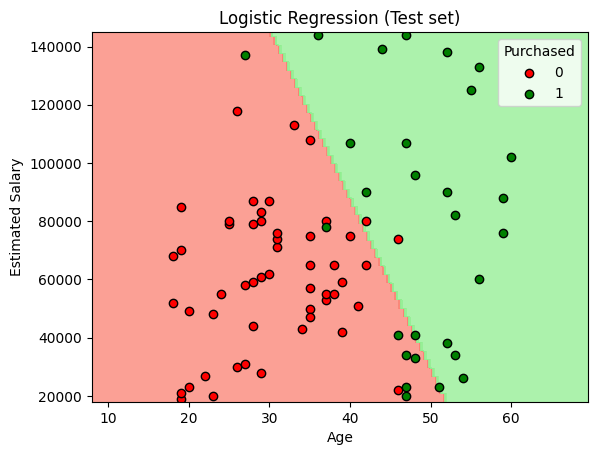

In [8]:
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.5),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 50))

plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('salmon', 'lightgreen')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j, edgecolors='k')

plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(title='Purchased')
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. Logistic regression can be used for classification by applying a decision threshold, which turns the probabilities into rigid categories.

2. The customers who are more likely to purchase a car are those who are older and have a higher estimated salary.

3. Two factors that cause low accuracy are: Non-linear relationships because if the  relationship in the data is curved or highly complex, a linear model will underperform. Outliers are also a problem because extreme values in age or salary could skew the linear decision boundary.


4. Additional features could be credit score and location (state or country).
Another preprocessing step could include implementing cross-validation to make sure the model doesn't overfit to a specific train/test split.